# KODEX 200 가격 확인

FinanceDataReader에서 받은 가격을 CSV로 저장한 뒤, 같은 파일을 다시 읽어 표와 그래프로 확인합니다.

In [1]:
# 파일 경로, 데이터 수집, 표 처리, 그래프에 필요한 도구를 불러옵니다.
from pathlib import Path

import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import pandas as pd

# 실습에서 사용할 종목과 조회 기간을 한곳에 모아 둡니다.
START = "2024-01-02"
END = "2024-03-29"
SYMBOL = "NAVER:069500"

In [2]:
# 노트북 폴더에서 실행해도 프로젝트의 data 폴더를 찾도록 기준 경로를 정합니다.
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == "notebooks" else cwd
csv_path = project_root / "data" / "kodex200_price.csv"
csv_path.parent.mkdir(parents=True, exist_ok=True)
print(f"저장 위치: {csv_path.relative_to(project_root)}")

저장 위치: data/kodex200_price.csv


In [3]:
# CSV가 없을 때만 가격을 내려받아 저장합니다.
if not csv_path.exists():
    downloaded = fdr.DataReader(SYMBOL, START, END)
    if downloaded.empty:
        raise RuntimeError("가격 데이터가 비어 있습니다.")
    downloaded.index.name = "Date"
    downloaded.to_csv(csv_path)

print(f"사용할 CSV: {csv_path.relative_to(project_root)}")

사용할 CSV: data/kodex200_price.csv


In [4]:
# 이후 작업은 인터넷이 아니라 저장해 둔 CSV를 다시 읽어 진행합니다.
prices = pd.read_csv(csv_path, parse_dates=["Date"])

# 필요한 열과 시작일·종료일이 요청한 조건과 맞는지 확인합니다.
required = {"Date", "Open", "High", "Low", "Close", "Volume", "Change"}
if not required.issubset(prices.columns):
    raise RuntimeError(f"필수 열이 없습니다: {required - set(prices.columns)}")
if prices["Date"].min() != pd.Timestamp(START):
    raise RuntimeError("첫 날짜가 요청과 다릅니다.")
if prices["Date"].max() != pd.Timestamp(END):
    raise RuntimeError("마지막 날짜가 요청과 다릅니다.")

print(f"확인 완료: {len(prices)}행, {prices['Date'].min().date()} ~ {prices['Date'].max().date()}")

확인 완료: 61행, 2024-01-02 ~ 2024-03-29


In [5]:
# 표의 처음과 마지막을 나란히 확인합니다.
display(prices.head())
display(prices.tail())

,Date,Open,High,Low,Close,Volume,Change
0,2024-01-02,34157,34676,34100,34541,7815352,0.006088
1,2024-01-03,34147,34147,33583,33583,8532058,-0.027735
2,2024-01-04,33325,33555,33199,33287,9353614,-0.008814
3,2024-01-05,33276,33382,33136,33194,7018655,-0.002794
4,2024-01-08,33368,33455,33047,33084,5648786,-0.003314


,Date,Open,High,Low,Close,Volume,Change
56,2024-03-25,35939,36071,35576,35654,4958616,-0.003939
57,2024-03-26,35953,36371,35924,36004,6883660,0.009817
58,2024-03-27,35818,36123,35786,36024,5724639,0.000555
59,2024-03-28,36009,36191,35914,36004,4985227,-0.000555
60,2024-03-29,36162,36266,35949,36123,5267314,0.003305


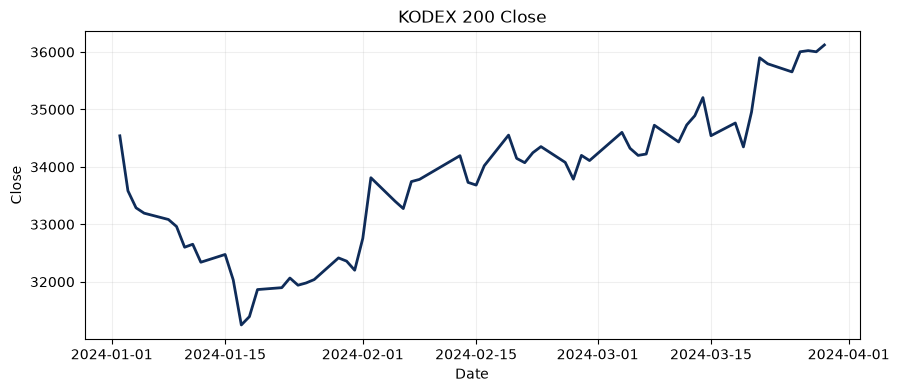

In [6]:
# Date를 가로축, Close를 세로축으로 종가 흐름을 그립니다.
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(prices["Date"], prices["Close"], color="#0F2C59", linewidth=2)
ax.set(title="KODEX 200 Close", xlabel="Date", ylabel="Close")
ax.grid(alpha=0.2)
plt.show()